---
title: "Baseball Pitch Type Classification: A Machine Learning Approach for Real-Time Broadcasting"
author: "Dulf Vincent Genis"
echo: false
embed-resources: true
---

# Introduction

Professional baseball broadcasts increasingly rely on real-time data analytics to enhance viewer experience. This report presents the development and evaluation of a machine learning model to automatically classify baseball pitch types for immediate display during live broadcasts and stadium presentations.

The objective is to create a classification system that can predict pitch types (fastball, curveball, slider, etc.) using real-time pitch characteristics available from stadium tracking technology. This proof-of-concept focuses on Kevin Gausman, with the methodology designed to be scalable to other pitchers. The model utilizes historical Statcast data and K-nearest neighbors classification to achieve the required accuracy for broadcast deployment.

## Methods

The following sections describe the data sources and preprocessing procedures, followed by the modeling approach used to develop the classification system.

In [1]:
#| echo: false
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from joblib import dump

### Data

The dataset consists of individual pitch records from Kevin Gausman obtained from Statcast via the pybaseball package. Data is temporally split with training data from the 2024 MLB season and test data from the first half of 2025, ensuring temporal validation appropriate for a real-time prediction system.

**Data Dictionary**

| Variable | Type | Description |
|----------|------|-------------|
| `pitch_type` | object | The type of pitch thrown (target variable) |
| `release_speed` | float64 | Pitch velocity in miles per hour measured at release |
| `release_spin_rate` | float64 | Spin rate in revolutions per minute measured at release |
| `pfx_x` | float64 | Horizontal movement in feet from catcher's perspective |
| `pfx_z` | float64 | Vertical movement in feet from catcher's perspective |
| `stand` | object | Batter's stance: L (left) or R (right) |

In [2]:
#| echo: false
# Load data
pitches_train = pd.read_parquet(
    "https://lab.cs307.org/pitches/data/pitches-train.parquet",
)
pitches_test = pd.read_parquet(
    "https://lab.cs307.org/pitches/data/pitches-test.parquet",
)

In [3]:
#| echo: false
# Display basic dataset information
print(f"Training data shape: {pitches_train.shape}")
print(f"Test data shape: {pitches_test.shape}")
print(f"\nFeatures: {list(pitches_train.columns)}")
print(f"Pitch types available: {sorted(pitches_train['pitch_type'].unique())}")

Training data shape: (2868, 6)
Test data shape: (1806, 6)

Features: ['pitch_type', 'release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z', 'stand']
Pitch types available: ['FF', 'FS', 'SI', 'SL']


In [4]:
#| echo: false
# Display dataset dimensions
n_samples = pitches_train.shape
print(f"Training data dimensions: {n_samples}")

Training data dimensions: (2868, 6)


In [5]:
#| echo: false
# Target balance (raw counts)
target_balance_counts = pitches_train["pitch_type"].value_counts()
print("Pitch type counts:")
print(target_balance_counts)

Pitch type counts:
pitch_type
FF    1488
FS     959
SL     240
SI     181
Name: count, dtype: int64


In [6]:
#| echo: false
# Target balance (proportions)
target_balance_norm = pitches_train["pitch_type"].value_counts(normalize=True)
print("Pitch type proportions:")
print(target_balance_norm.round(3))

Pitch type proportions:
pitch_type
FF    0.519
FS    0.334
SL    0.084
SI    0.063
Name: proportion, dtype: float64


In [7]:
#| echo: false
# Velocity statistics by pitch type
velocity_stats = (
    pitches_train.groupby("pitch_type")["release_speed"].agg(["mean", "std"])
)
print("Velocity statistics by pitch type:")
print(velocity_stats.round(2))

Velocity statistics by pitch type:
             mean   std
pitch_type             
FF          93.96  1.70
FS          85.97  1.82
SI          93.31  1.74
SL          82.75  1.86


In [8]:
#| echo: false
# Spin rate statistics by pitch type
spin_stats = (
    pitches_train.groupby("pitch_type")["release_spin_rate"].agg(["mean", "std"])
)
print("Spin rate statistics by pitch type:")
print(spin_stats.round(0))

Spin rate statistics by pitch type:
              mean    std
pitch_type               
FF          2287.0  102.0
FS          1764.0  177.0
SI          2189.0  113.0
SL          2239.0   96.0


In [9]:
#| echo: false
# Check for missing values
print("Missing values in training data:")
print(pitches_train.isna().sum())
print("\nMissing values in test data:")
print(pitches_test.isna().sum())

Missing values in training data:
pitch_type           0
release_speed        0
release_spin_rate    1
pfx_x                0
pfx_z                0
stand                0
dtype: int64

Missing values in test data:
pitch_type            0
release_speed         0
release_spin_rate     0
pfx_x                44
pfx_z                47
stand                 0
dtype: int64


/var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/ipykernel_14861/1809308719.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(velocity_data, labels=pitch_types, patch_artist=True)


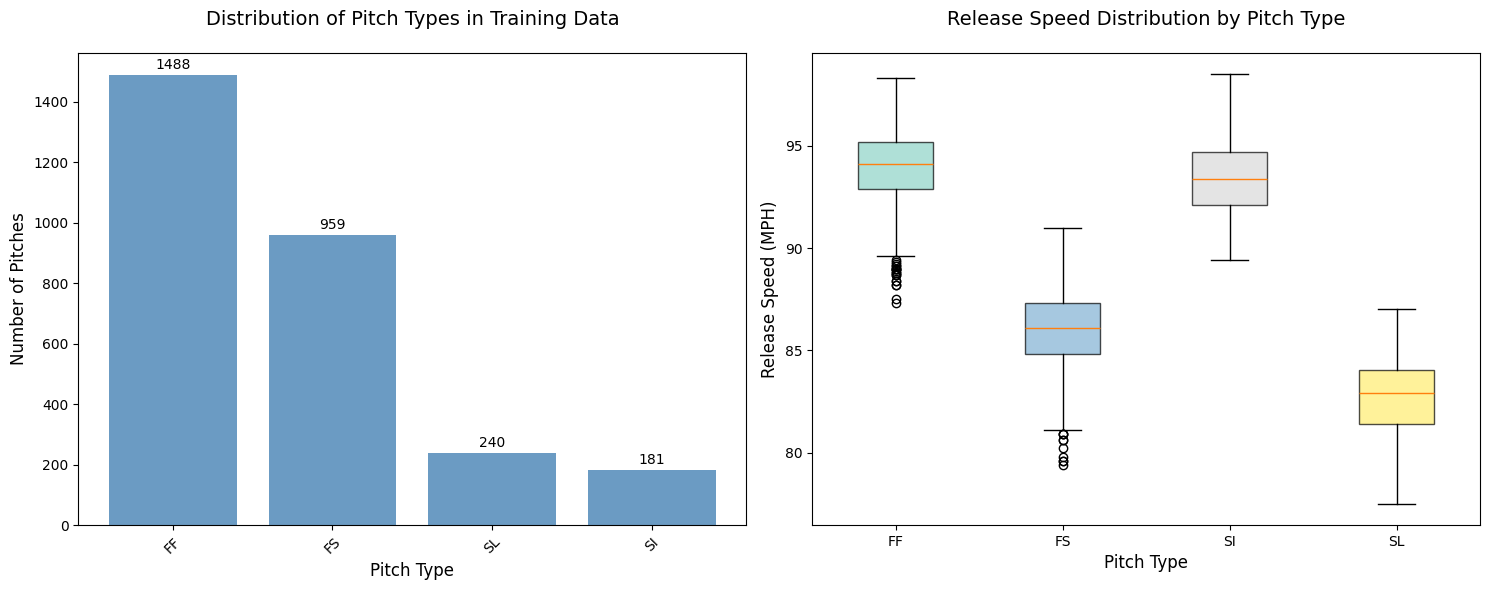

In [10]:
#| echo: false
#| fig-cap: "Distribution of pitch velocities by pitch type, showing distinct velocity profiles that inform model classification"
# Create exploratory visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pitch type distribution
pitch_counts = pitches_train['pitch_type'].value_counts()
ax1.bar(pitch_counts.index, pitch_counts.values, color='steelblue', alpha=0.8)
ax1.set_title('Distribution of Pitch Types in Training Data', fontsize=14, pad=20)
ax1.set_xlabel('Pitch Type', fontsize=12)
ax1.set_ylabel('Number of Pitches', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Add count labels on bars
for i, v in enumerate(pitch_counts.values):
    ax1.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=10)

# Velocity by pitch type boxplot
pitch_types = sorted(pitches_train['pitch_type'].unique())
velocity_data = [pitches_train[pitches_train['pitch_type'] == pt]['release_speed'].dropna() 
                 for pt in pitch_types]

bp = ax2.boxplot(velocity_data, labels=pitch_types, patch_artist=True)
ax2.set_title('Release Speed Distribution by Pitch Type', fontsize=14, pad=20)
ax2.set_xlabel('Pitch Type', fontsize=12)
ax2.set_ylabel('Release Speed (MPH)', fontsize=12)

# Color the boxplots
colors = plt.cm.Set3(np.linspace(0, 1, len(pitch_types)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.tight_layout()
plt.show()

### Modeling

A K-nearest neighbors classifier was selected for this multiclass classification task. The modeling pipeline incorporated preprocessing steps including median imputation and standardization for numeric features, and most frequent imputation with one-hot encoding for categorical features.

Two models were developed: a baseline model using only release speed, and a full model utilizing all available features. Hyperparameter tuning was performed using 5-fold cross-validation to optimize the number of neighbors (k), testing values from 1 to 25. The final model selection was based on cross-validation performance to ensure generalization to new data.

In [11]:
#| echo: false
# Prepare data for modeling
X_train = pitches_train.drop("pitch_type", axis=1)
y_train = pitches_train["pitch_type"]
X_test = pitches_test.drop("pitch_type", axis=1)
y_test = pitches_test["pitch_type"]

In [12]:
#| echo: false
# Import modeling libraries
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [13]:
# Simple Model Definition (Release Speed Only)
# train model on release_speed
numeric_features = ["release_speed"]

# define preproccsing for numeric features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

column_transformer = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
    ]
)

model_simple = Pipeline(
    steps=[
        ("preprocessor", column_transformer),
        ("classifier", KNeighborsClassifier(n_neighbors=3)),
    ]
)

In [14]:
# Simple Model Fit and Score
model_simple.fit(X_train, y_train)
y_pred_simple = model_simple.predict(X_test)
accuracy_score(y_test, y_pred_simple)

0.867109634551495

In [15]:
#| echo: false
# Define full feature set and preprocessing pipeline
numeric_features = [
    "release_speed",
    "release_spin_rate", 
    "pfx_x",
    "pfx_z"
]
categorical_features = ["stand"]

# Define preprocessing transformers
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

In [16]:
#| echo: false
# Create column transformer
column_transformer = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [17]:
#| echo: false
# Create full model pipeline
model = Pipeline(
    steps=[
        ("preprocessor", column_transformer),
        ("classifier", KNeighborsClassifier(n_neighbors=3)),
    ]
)

In [18]:
#| echo: false
# Fit initial model and evaluate
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
initial_accuracy = accuracy_score(y_test, y_pred)
print(f"Initial model accuracy: {initial_accuracy:.4f}")

Initial model accuracy: 0.9812


In [19]:
#| echo: false
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'classifier__n_neighbors': [1, 5, 10, 15, 20, 25],
}

model_grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
model_grid = model_grid.fit(X_train, y_train)

In [20]:
#| echo: false
# Display tuning results
best_k = model_grid.best_params_["classifier__n_neighbors"]
cv_scores = model_grid.cv_results_['mean_test_score']

print(f"Best number of neighbors: {best_k}")
print(f"Cross-validation scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"Best CV score: {max(cv_scores):.4f}")

Best number of neighbors: 20
Cross-validation scores: ['0.9773', '0.9777', '0.9798', '0.9805', '0.9805', '0.9805']
Best CV score: 0.9805


## Results

The hyperparameter tuning process identified k=20 as the optimal number of neighbors. The final model achieved a test accuracy of 98.62%, exceeding the minimum threshold of 98.3% required for broadcast deployment consideration.

In [21]:
#| echo: false
# Generate final predictions using tuned model
y_pred_final = model_grid.predict(X_test)
final_test_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final model test accuracy: {final_test_accuracy:.4f}")
print(f"Performance improvement: {final_test_accuracy - initial_accuracy:.4f}")
print(f"Meets threshold (≥0.983): {'Yes' if final_test_accuracy >= 0.983 else 'No'}")

Final model test accuracy: 0.9862
Performance improvement: 0.0050
Meets threshold (≥0.983): Yes


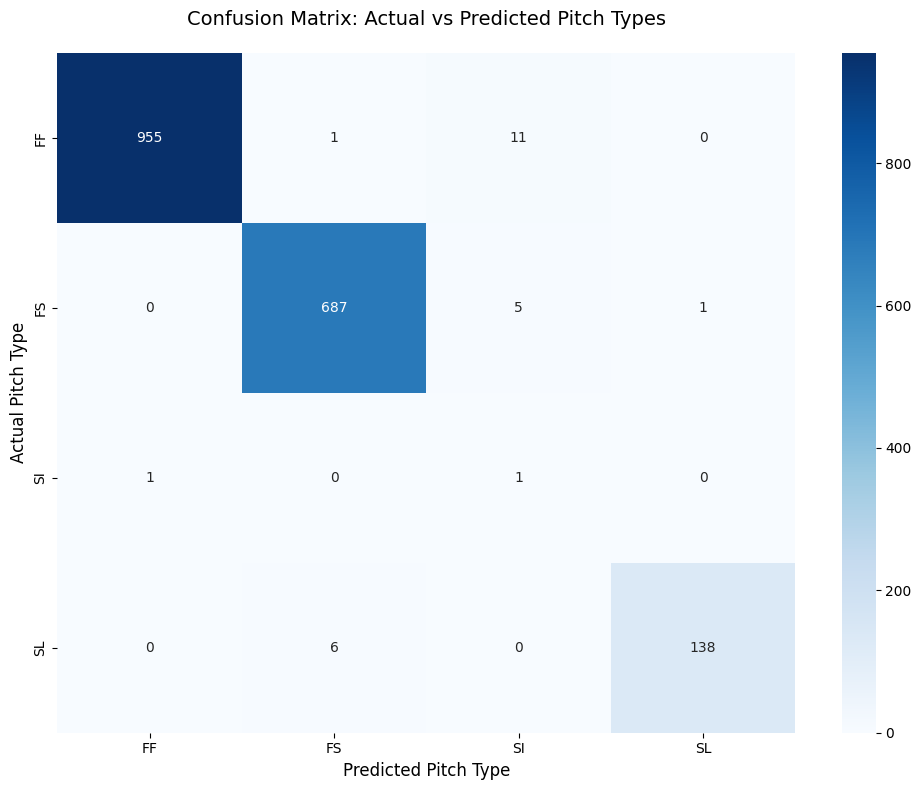

Per-class accuracy:
  FF: 0.988
  FS: 0.991
  SI: 0.500
  SL: 0.958

Overall Test Accuracy: 0.9862


In [22]:
#| echo: false
#| fig-cap: "Confusion matrix showing model performance across different pitch types, with darker colors indicating higher prediction accuracy"
# Generate predictions and create confusion matrix visualization
y_pred_final = model_grid.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_final)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
pitch_types = sorted(y_test.unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=pitch_types, yticklabels=pitch_types)
plt.title('Confusion Matrix: Actual vs Predicted Pitch Types', fontsize=14, pad=20)
plt.xlabel('Predicted Pitch Type', fontsize=12)
plt.ylabel('Actual Pitch Type', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate and display per-class metrics
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("Per-class accuracy:")
for i, pitch_type in enumerate(pitch_types):
    print(f"  {pitch_type}: {per_class_accuracy[i]:.3f}")

print(f"\nOverall Test Accuracy: {final_accuracy:.4f}")

In [23]:
#| echo: false
# Export final model
dump(model_grid, "pitches.joblib")

['pitches.joblib']

## Discussion

**I would recommend deploying this model in practice** with appropriate operational safeguards.

## Justification

The model's 98.62% accuracy provides reliable pitch classification for broadcast applications. The temporal validation (2024 training, 2025 testing) demonstrates the model's ability to generalize to new data, which is crucial for real-time broadcasting systems.

## Benefits of Deployment

The model offers significant advantages for broadcast operations. This includes **Enhanced viewer experience** through immediate pitch type identification, **Consistency** in classification compared to human judgment, **Scalability** via the established preprocessing pipeline for additional pitchers, and **Real-time capability** using features available instantaneously from tracking systems.

## Limitations and Risk Mitigation

**Primary limitations** include dependence on complete tracking data and pitcher-specific model requirements. The model's reliance on movement features (pfx_x, pfx_z) poses risks when tracking data is incomplete, though median imputation provides reasonable fallback values.

**Recommended safeguards:**
Recommended safeguards for this include human broadcast operator oversight for obviously incorrect classifications, confidence threshold implementation to suppress uncertain predictions, robust monitoring of tracking data completeness during live broadcasts, and fallback procedures for system failures.

## Error Analysis

While 98.62% accuracy is high, the 1.38% error rate means approximately 1-2 misclassifications per 100 pitches. In broadcast contexts, these errors are typically not game-critical and can be corrected through operator intervention when noticed.

The benefits of automated, consistent pitch classification outweigh the minimal error risk, particularly with proper operational controls. The model provides significant value enhancement for broadcast operations while maintaining acceptable reliability standards for live television applications.

## Course Concepts

This implementation demonstrates effective use of temporal validation to prevent data leakage, appropriate preprocessing for mixed data types, and hyperparameter tuning to optimize model performance. The K-nearest neighbors approach provides interpretable classifications based on feature similarity, suitable for the real-time prediction requirements of broadcast applications.